# **Import Libraries**

In [ ]:
pip install nlp-id

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 661.5/661.5 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 58.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 55.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 71.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 12.5 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=48afe1c7a6bbbe893a6414fc13fc76faae60225785344cbd018e9e92f3959157
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled

In [ ]:
!pip install transformers torch

In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.0 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import re
import csv
import requests
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import numpy as np
import nltk
import tensorflow as tf
import torch
import evaluate

from nlp_id.tokenizer import Tokenizer as NLPIDTokenizer
from nlp_id.lemmatizer import Lemmatizer
from nlp_id.stopword import StopWord

from io import StringIO
from io import BytesIO
from wordcloud import WordCloud

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import confusion_matrix

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from transformers import AutoModel, AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, TrainerCallback, get_linear_schedule_with_warmup

from torch.optim import AdamW
from torch.utils.data import Dataset, DataLoader

nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

# **Load and Review Dataset**

This `dana_reviews` dataset was scraped from Google Play reviews utilizing google play scraper API. The original dataset contained 20.000 reviews but it was reduced to 1000 reviews due to hardware limitations.

In [ ]:
df_reviews = pd.read_csv('dana_reviews.csv')

In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   content  1000 non-null   object
dtypes: object(1)
memory usage: 7.9+ KB


In [ ]:
print(df_reviews)

                                               content
0    sering terjadi bug dan lambat, sinyal bagus ta...
1    pengaturan terbaru, agak menyusahkan, seperti ...
2    Aplikasi DANA menurut saya sangat membantu dal...
3    Tolong aplikasi DANA dibersihkan dari fitur ti...
4    saya mengalami masalah dengan dana instant ter...
..                                                 ...
995  uninstall akun Dana apa saldo bisa hilang.suda...
996  keamanan dana sekarang kurang ya ada transaksi...
997  bagus, mantap, sepertinya aplikasi dana blm ad...
998  setiap transaksi ada dapat poin, tapi poin say...
999  makin hari makin mengecewakan aplikasi ini ko ...

[1000 rows x 1 columns]


In [ ]:
# Checking missing values
total_missing = df_reviews.isnull().sum()
print(f'Total missing values: {total_missing}')

Total missing values: content    0
dtype: int64


# **Data Prepocessing**

In [ ]:
# Convert to lowercase
def casefolding_text(text):
  return text.lower()

# Removing text from unnecessary elements
def cleaning_text(text):
  text = re.sub(r'[^^\x00-\x7F]+', '', text)  # keep only letters, numbers, symbol, and spaces
  text = re.sub(r'([a-z])\1{2,}', r'\1\1', text)  # trimming extra letters to just two letters
  text = re.sub(r'([^\w\s])\1+', r'\1', text)  # removing double punctuation
  text = re.sub(r'\s+', ' ', text)  # removing extra spaces
  text = text.strip(' ')  # removing spaces on both sides of a sentence
  return text

# Tokenizing text
def tokenizing_text(text):
  tokenizer = NLPIDTokenizer()
  return  tokenizer.tokenize(text)

slang_dict = {
    "apk":"aplikasi", "app":"aplikasi", "apps":"aplikasi", "abis":"habis", "aj":"saja", "aja":"saja", "ajh":"saja", "ak":"saya", "aku":"saya", "ampe":"sampai", "aq":"saya", "banget":"sekali", "bangett":"sekali", "bgmn":"bagaimana", "bgs":"bagus", "bgt":"sekali", "bgtt":"sekali", "blm":"belum", "blum":"belum", "blom":"belum", "belom":"belum", "bnyk":"banyak", "bs":"bisa", "cb":"coba", "cepet":"cepat", "cpt":"cepat", "d":"di", "dah":"sudah", "dlm":"dalam", "dlu":"dulu", "dm":"chat", "engga":"tidak", "enggak":"tidak", "eror":"error", "g":"tidak", "ggl":"gagal", "gabisa":"tidak bisa", "gak":"tidak", "gk":"tidak", "gogle":"google", "gugel":"google", "gua":"saya", "gue":"saya", "gmn":"bagaimana", "gimana":"bagaimana", "gw":"saya", "gwh":"saya", "hbs":"habis", "jg":"juga", "jlk":"jelek", "jls":"jelas", "karna":"karena", "krn":"karena", "kalo":"kalau", "kl":"kalau", "klo":"kalau", "klw":"kalau", "knp":"mengapa", "kenapa":"mengapa", "kumplit":"lengkap", "komplit":"lengkap", "krg":"kurang", "lemot":"lambat", "lg":"lagi", "min":"admin", "ngak":"tidak", "nggak":"tidak", "ngga":"tidak", "nnti":"nanti", "nyaa":"nya", "ny":"nya", "nyh":"nya", "nyah":"nya", "ok":"oke", "pdhl":"padahal", "prh":"parah", "pls":"tolong", "sampe":"sampai", "sdh":"sudah", "sdkt":"sedikit", "sgt":"sangat", "smp":"sampai", "sj":"saja", "skl":"sekali", "skrg":"sekarang", "smg":"semoga", "spy":"supaya", "sy":"saya", "sya":"saya", "tapi":"tetapi", "tpi":"tetapi", "tp":"tetapi", "td":"tadi", "tdk":"tidak", "tf":"transfer", "tiap":"setiap", "tlg":"tolong", "trus":"terus", "trs":"terus", "udah":"sudah", "udh":"sudah", "y":"ya", "yaa":"ya", "yg":"yang"
}

# Formalizing text
def formalizing_text(text, slang_dict):
  return [slang_dict.get(word, word) for word in text]

# Lemmatization text
def lemmatization_text(text):
  lemmatizer = Lemmatizer()
  return lemmatizer.lemmatize(text)

# Removing stopwords
def removing_stopwords(text):
  stopword = StopWord()
  crusial_words = ["tidak", "kurang", "belum"]
  # modifying list of stopwords in library
  if hasattr(stopword, "stopword"):
        stopword.stopword = {
            w for w in stopword.stopword if w not in crusial_words
        }
  return stopword.remove_stopword(text)

In [ ]:
def prepocessing_text(text):
  text = casefolding_text(text)
  text = cleaning_text(text)
  text = tokenizing_text(text) # text is now list of strings
  text = formalizing_text(text, slang_dict) # text is still list of strings
  text = " ".join(text) # Join the list of words back into a single string
  text = lemmatization_text(text)
  text = removing_stopwords(text)
  return text

In [ ]:
prepocessed_text = df_reviews['content'].apply(prepocessing_text)

In [ ]:
prepocessed_text

,content
0,bug lambat sinyal bagus aplikasi patah patah u...
1,atur susah paksa customer deposit 2x kena admi...
2,aplikasi dana bantu hidup tampil sederhana mud...
3,tolong aplikasi dana bersih fitur game dana pl...
4,alam dana instant error aju ulang lancar kah b...
...,...
995,uninstall akun dana saldo hilang 4hari akun ng...
996,aman dana transaksi ga tau tuju dana gada noti...
997,bagus mantap aplikasi dana pribadi aplikasi da...
998,transaksi poin poin ga nambah tu bukti transak...


In [ ]:
# save preprocessed_text as csv
prepocessed_text.to_csv('prepocessed_text.csv', index=False)

# **Labelling Data**

In [ ]:
def load_lexicon_xlsx(url):
    # Convert GitHub URL to raw download URL
    raw_url = url.replace('github.com', 'raw.githubusercontent.com').replace('/blob/', '/')

    response = requests.get(raw_url)
    df = pd.read_excel(BytesIO(response.content))

    lexicon = dict(zip(df.iloc[:, 0], df.iloc[:, 1].astype(int)))
    return lexicon

lexicon_positive = load_lexicon_xlsx('https://github.com/agushendra7/twitter-sentiment-analysis-using-inset-and-random-forest/blob/main/dataset/kamus_positive.xlsx')
lexicon_negative = load_lexicon_xlsx('https://github.com/agushendra7/twitter-sentiment-analysis-using-inset-and-random-forest/blob/main/dataset/kamus_negative.xlsx')

In [ ]:
def labelling_data(prepocessed_text):
  score = 0
  negation = ["tidak", "kurang", "belum"]

  prepocessed_text = prepocessed_text.split()
  for i, word in enumerate(prepocessed_text):
    word_score = 0
    if word in lexicon_positive:
      word_score = lexicon_positive[word]
    elif word in lexicon_negative:
      word_score = lexicon_negative[word]
    # handling negation
    if word_score != 0:
      if i > 0 and prepocessed_text[i - 1] in negation:
        word_score *= -1
    score += word_score

  if score > 0:
    polarity = 'positive'
  elif score < 0:
    polarity = 'negative'
  else:
    polarity = 'neutral'

  return score, polarity

In [ ]:
sentiment_results = prepocessed_text.apply(labelling_data)

In [ ]:
# Convert prepocessed_text into a dataframe
df_prepocessed_text = pd.DataFrame({'content': prepocessed_text})

# Extract the scores and polarities from sentiment_results
scores = [item[0] for item in sentiment_results]
polarities = [item[1] for item in sentiment_results]

# Assign the list of scores and polarities to new column in dataframe
df_prepocessed_text['score'] = scores
df_prepocessed_text['polarity'] = polarities

In [ ]:
df_prepocessed_text

,content,score,polarity
0,bug lambat sinyal bagus aplikasi patah patah u...,-9,negative
1,atur susah paksa customer deposit 2x kena admi...,-1,negative
2,aplikasi dana bantu hidup tampil sederhana mud...,22,positive
3,tolong aplikasi dana bersih fitur game dana pl...,6,positive
4,alam dana instant error aju ulang lancar kah b...,10,positive
...,...,...,...
995,uninstall akun dana saldo hilang 4hari akun ng...,15,positive
996,aman dana transaksi ga tau tuju dana gada noti...,12,positive
997,bagus mantap aplikasi dana pribadi aplikasi da...,20,positive
998,transaksi poin poin ga nambah tu bukti transak...,17,positive


# **Data  Exploration**

In [ ]:
def plot_sentiment_polarity(dataframe, column_name):
  sns.set(style='whitegrid')
  custom_palette = {
        "positive": "#4FB06D",
        "negative": "#BF2C34",
        "neutral": "#438FFF",
    }

  plt.figure(figsize=(20,8))
  ax = sns.countplot(
      data=dataframe,
      x=column_name,
      palette=custom_palette,
      hue=column_name,
      linewidth=0.1,
      order=['positive', 'negative', 'neutral']
  )

  ax.yaxis.grid(False)

  for container in ax.containers:
        ax.bar_label(
            container,
            fontsize=14,
            weight="bold",
            padding=8,
            color="#333333",
        )

  plt.title('Count of Sentiment Polarity on Dana Reviews', fontsize=24, pad=32, weight='bold')
  plt.xlabel('Sentiment', fontsize=16, labelpad=16, weight='bold')
  plt.ylabel('Count', fontsize=16, labelpad=16, weight='bold')

  # delete top and right frame
  sns.despine(top=True, right=True, left=False, bottom=False)

  plt.tight_layout()
  plt.show()

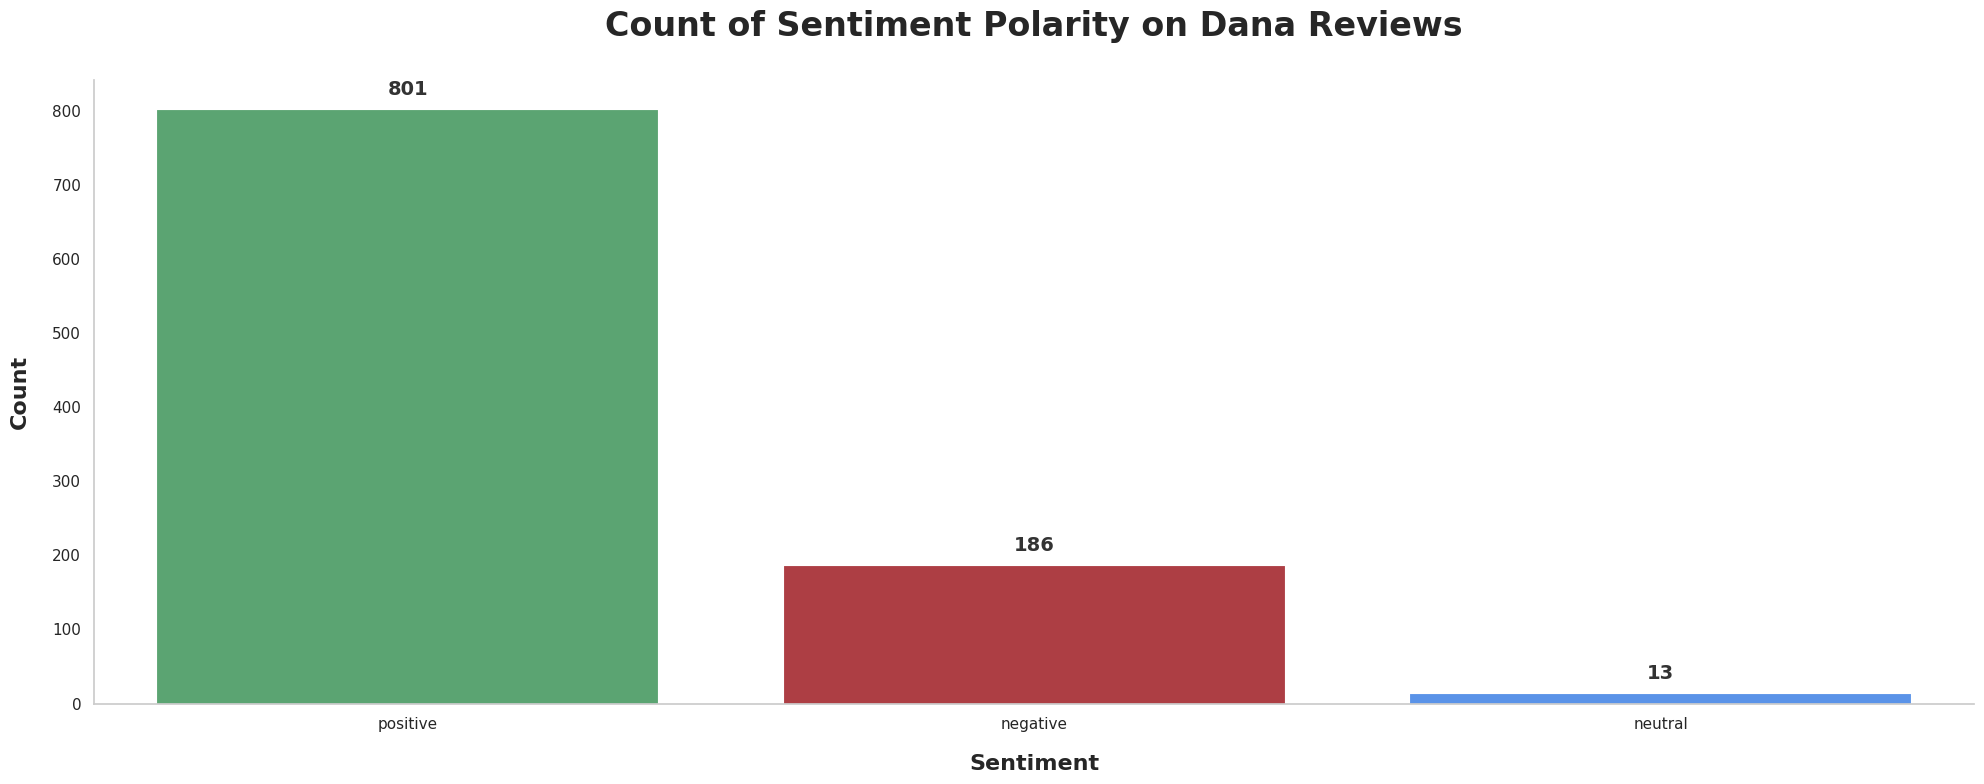

In [ ]:
plot_sentiment_polarity(df_prepocessed_text, 'polarity')

In [ ]:
def generate_worldcloud_data(dataframe, column_name):
  all_words = []
  for text_string in dataframe[column_name]:
    # Split the string into individual words
    words = text_string.split()
    all_words.extend(words)

  all_words_text = ' '.join(all_words)
  worldcloud = WordCloud(width=800, height=400, background_color='white', colormap='Blues').generate(all_words_text)

  plt.figure(figsize=(10, 5))
  plt.imshow(worldcloud, interpolation='bilinear')
  plt.title('Most Frequently Used Words on Dana Reviews', pad=16, weight='bold')
  plt.axis('off')
  plt.show()

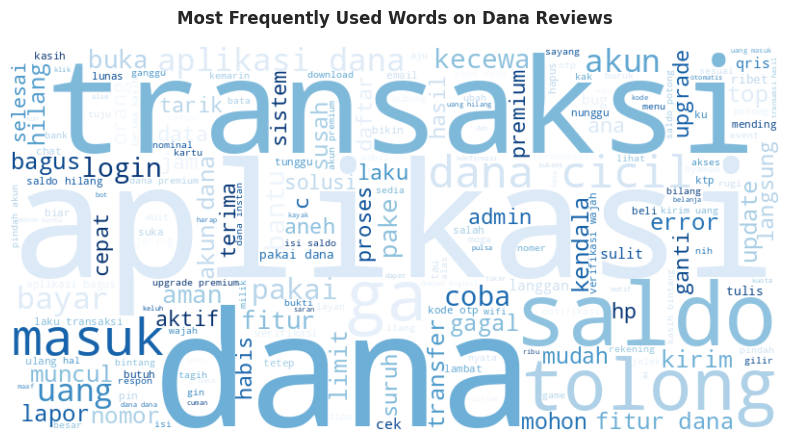

In [ ]:
generate_worldcloud_data(df_prepocessed_text, 'content')

In [ ]:
def generate_worldcloud_by_sentiment(dataframe, polarity, column_name):
  filtered_df = dataframe[dataframe["polarity"] == polarity]

  all_words = []
  for text_string in filtered_df[column_name]:
    # Split the string into individual words
    words = text_string.split()
    all_words.extend(words)

  if not all_words:
    print(f"Tidak ada data kata untuk sentimen: {polarity}")
    return

  all_words_text = " ".join(all_words)

  polarity_lower = str(polarity).lower()
  if "positive" in polarity_lower:
    cmap = "Greens"
  elif "negative" in polarity_lower:
    cmap = "Reds"
  else:
    cmap = "Blues"

  worldcloud = WordCloud(width=800, height=400, background_color='white', colormap=cmap).generate(all_words_text)

  plt.figure(figsize=(10, 5))
  plt.imshow(worldcloud, interpolation='bilinear')
  plt.title(f"Most Frequently Used Words on {polarity} Dana Reviews", pad=16, weight='bold')
  plt.axis('off')
  plt.show()

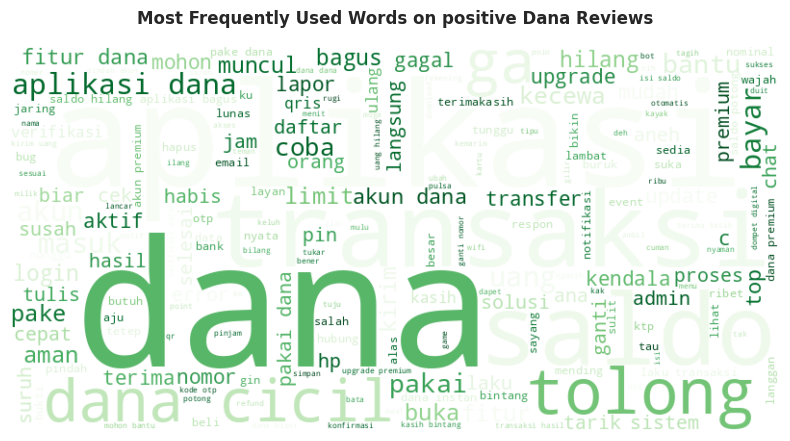

In [ ]:
generate_worldcloud_by_sentiment(df_prepocessed_text, 'positive', 'content')

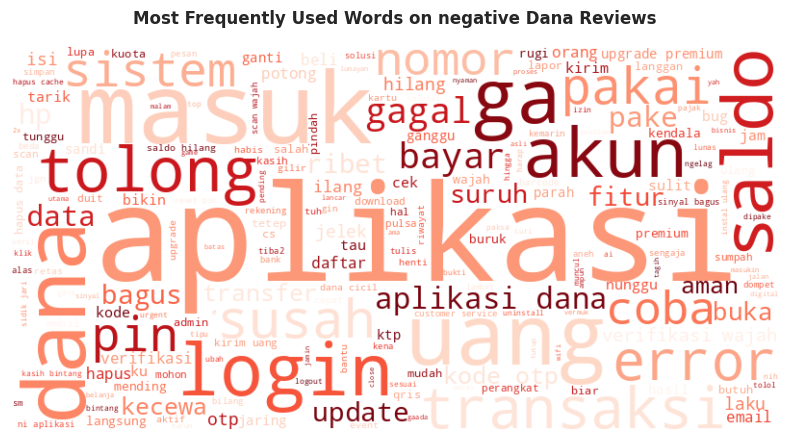

In [ ]:
generate_worldcloud_by_sentiment(df_prepocessed_text, 'negative', 'content')

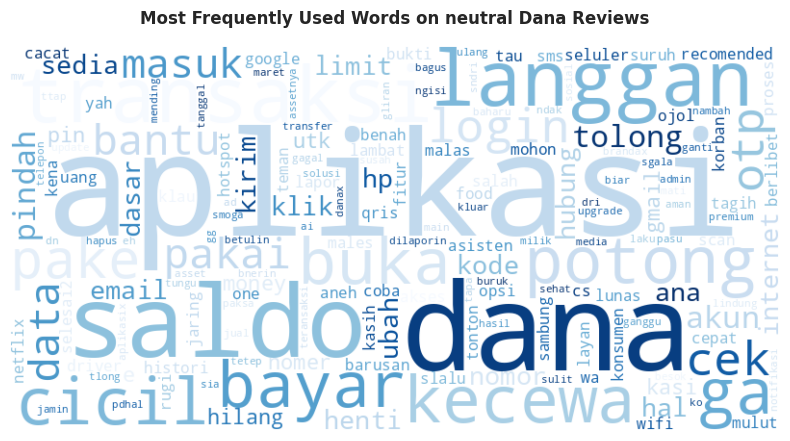

In [ ]:
generate_worldcloud_by_sentiment(df_prepocessed_text, 'neutral', 'content')

# **Data Preparation**

In [ ]:
# Extract text from data as X
def split_features(df, text_column):
  X = df[text_column]
  return X

def tokenizing_and_padding_text(text, max_features, max_len):
  tokenizer = Tokenizer(num_words=max_features, split=' ')
  tokenizer.fit_on_texts(text)

  sequences = tokenizer.texts_to_sequences(text)
  padded_sequences = pad_sequences(sequences, maxlen=max_len)

  return padded_sequences, tokenizer

In [ ]:
# Extract label column from data as Y
def split_label(df, label_column):
  y = df[label_column]
  return y

# One-hot encoding y label
def encode_label(labels):
  labelencoder = LabelEncoder()
  integer_encoded = labelencoder.fit_transform(labels)
  onehot_encoded = to_categorical(integer_encoded)
  return onehot_encoded, labelencoder

In [ ]:
def preparing_data(df, text_column, label_column, max_features, max_len):
  # Feature extraction
  X = split_features(df, text_column)
  X_processed, tokenizer = tokenizing_and_padding_text(X, max_features, max_len)

  # Label extraction
  Y = split_label(df, label_column)
  Y_processed, labelencoder = encode_label(Y)

  # Determine number of classes
  num_classes = Y_processed.shape[1]

  return X_processed, Y_processed, tokenizer, labelencoder, num_classes

In [ ]:
max_features = 100000
max_len = 100

X_processed, Y_processed, tokenizer, labelencoder, num_classes = preparing_data(df_prepocessed_text, 'content', 'polarity', max_features, max_len)

In [ ]:
print('Processed text data and padded text:\n', X_processed[:5], '\n')

Processed text data and padded text:
 [[   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0   89   98  143
    16    2  935  935   43  516  730  731    5   40   67    4   23    7
    20  415]
 [   0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0    0    0    0    0    0    0
     0    0    0    0    0    0    0    0  238   51  297  123 1335  253
   155   52   49   39  253   16  226 1336  298  356  451  936  160  299
    13  732  

In [ ]:
print('Processed label data:\n', Y_processed[:5], '\n')

Processed label data:
 [[1. 0. 0.]
 [1. 0. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]] 



In [ ]:
print('Number of classes:', num_classes)

Number of classes: 3


# **Modelling**

## **Model 1: LSTM**

In [ ]:
# Split data for training (70%)
X_train, X_temp, Y_train, Y_temp = train_test_split(X_processed, Y_processed, test_size=0.3, random_state=42)

# Split data for validation and testing from 30% remaining data
X_val, X_test, Y_val, Y_test = train_test_split(X_temp, Y_temp, test_size=0.5, random_state=42)

In [ ]:
print('Shape of training data:', X_train.shape, Y_train.shape)
print('Shape of validation data:', X_val.shape, Y_val.shape)
print('Shape of testing data:', X_test.shape, Y_test.shape)

Shape of training data: (700, 100) (700, 3)
Shape of validation data: (150, 100) (150, 3)
Shape of testing data: (150, 100) (150, 3)


In [ ]:
# Building LSTM model
def build_LSTM_model(max_features, input_length, max_len, num_classes):
  model = Sequential([
      Embedding(input_dim=max_features, output_dim=256, input_shape=(input_length,)),
      LSTM(64, dropout=0.2, recurrent_dropout=0.2, return_sequences=True),
      LSTM(32, dropout=0.2, recurrent_dropout=0.2),
      Dense(64, activation='relu'),
      Dense(32, activation='relu'),
      Dense(num_classes, activation='softmax')
  ])

  model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

  return model

In [ ]:
max_features = 100000
input_length = X_train.shape[1]
max_len = 100
num_classes = 3

LSTM_model = build_LSTM_model(max_features, input_length, max_len, num_classes)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:103: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
LSTM_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 100, 256)       │    25,600,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 100, 64)        │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,698,883 (98.03 MB)

 Trainable params: 25,698,883 (98.03 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Training LSTM model
def train_LSTM_model(model, X_train, Y_train, X_val, Y_val, epochs, batch_size):
  history = model.fit(
      X_train,
      Y_train,
      epochs=epochs,
      batch_size=batch_size,
      validation_data=(X_val, Y_val),
      callbacks=[EarlyStopping(monitor='val_loss', patience=3)]
  )

  return history

In [ ]:
history_LSTM = train_LSTM_model(LSTM_model, X_train, Y_train, X_val, Y_val, 20, 32)

Epoch 1/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 682ms/step - accuracy: 0.7786 - loss: 0.7452 - val_accuracy: 0.8067 - val_loss: 0.5382
Epoch 2/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 18s 633ms/step - accuracy: 0.8057 - loss: 0.5468 - val_accuracy: 0.8067 - val_loss: 0.5410
Epoch 3/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 629ms/step - accuracy: 0.8057 - loss: 0.5406 - val_accuracy: 0.8067 - val_loss: 0.5304
Epoch 4/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 627ms/step - accuracy: 0.8071 - loss: 0.4997 - val_accuracy: 0.8067 - val_loss: 0.4490
Epoch 5/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 636ms/step - accuracy: 0.8886 - loss: 0.3175 - val_accuracy: 0.8533 - val_loss: 0.4103
Epoch 6/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 639ms/step - accuracy: 0.9629 - loss: 0.1342 - val_accuracy: 0.8333 - val_loss: 0.5059
Epoch 7/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 14s 643ms/step - accuracy: 0.9786 - loss: 0.0676 - val_accuracy: 0.8600 - val_loss: 0.5726
Epoch 8/20
22/22 ━━━━━━━━━━━━━━━━━━━━ 21s 644ms/step - accuracy: 0.9814 - loss: 0.0577 - val_accu

In [ ]:
# Testing data
Y_prediction = LSTM_model.predict(X_test)

5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 290ms/step


In [ ]:
# Evaluate model
train_loss_LSTM, train_accuracy_LSTM = LSTM_model.evaluate(X_train, Y_train, verbose=0)
validation_loss_LSTM, validation_accuracy_LSTM = LSTM_model.evaluate(X_val, Y_val, verbose=0)
test_loss_LSTM, test_accuracy_LSTM = LSTM_model.evaluate(X_test, Y_test, verbose=0)

print(f'Train Loss: {train_loss_LSTM:.4f}')
print(f'Train Accuracy: {train_accuracy_LSTM:.4f}')
print(f'Validation Loss: {validation_loss_LSTM:.4f}')
print(f'Validation Accuracy: {validation_accuracy_LSTM:.4f}')
print(f'Test Loss: {test_loss_LSTM:.4f}')
print(f'Test Accuracy: {test_accuracy_LSTM:.4f}')

# Convert predictions and true labels to class indices
Y_pred_classes = np.argmax(Y_prediction, axis=1)
Y_test_classes = np.argmax(Y_test, axis=1)

# Get classification report as a dictionary
report_dict_LSTM = classification_report(Y_test_classes, Y_pred_classes, target_names=labelencoder.classes_, output_dict=True)

precision_LSTM = report_dict_LSTM['weighted avg']['precision'] # using weighted avg because the dataset might be imbalanced
recall_LSTM = report_dict_LSTM['weighted avg']['recall']
f1_LSTM = report_dict_LSTM['weighted avg']['f1-score']

df_LSTM_summary = pd.DataFrame({
    'Model': ['LSTM'],
    'Train Loss': [train_loss_LSTM],
    'Train Accuracy': [train_accuracy_LSTM],
    'Validation Loss': [validation_loss_LSTM],
    'Validation Accuracy': [validation_accuracy_LSTM],
    'Test Accuracy': [test_accuracy_LSTM],
    'Test Loss': [test_loss_LSTM],
    'Precision': [precision_LSTM],
    'Recall': [recall_LSTM],
    'F1 Score': [f1_LSTM]
})

df_LSTM_summary

Train Loss: 0.0450
Train Accuracy: 0.9857
Validation Loss: 0.5690
Validation Accuracy: 0.8533
Test Loss: 0.6491
Test Accuracy: 0.8200


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


,Model,Train Loss,Train Accuracy,Validation Loss,Validation Accuracy,Test Accuracy,Test Loss,Precision,Recall,F1 Score
0,LSTM,0.045005,0.985714,0.568975,0.853333,0.82,0.649062,0.802696,0.82,0.808878


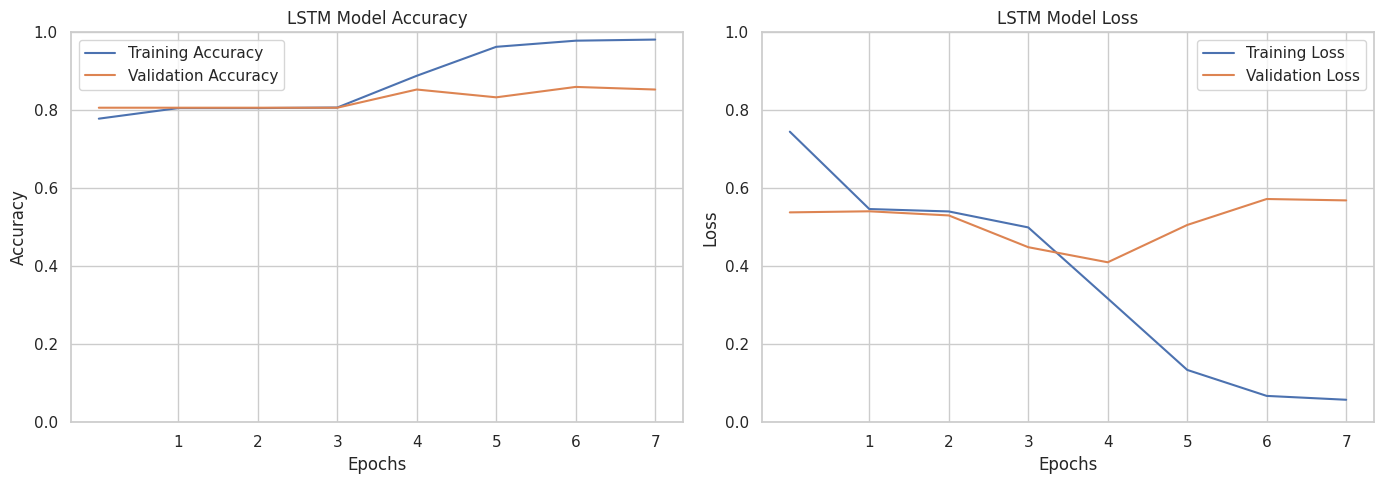

In [ ]:
# Plotting accuracy and loss
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax[0].plot(history_LSTM.history['accuracy'], label='Training Accuracy')
ax[0].plot(history_LSTM.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_title('LSTM Model Accuracy')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].set_ylim(0, 1)
ax[0].set_xticks(range(1, 8, 1))

# Loss plot
ax[1].plot(history_LSTM.history['loss'], label='Training Loss')
ax[1].plot(history_LSTM.history['val_loss'], label='Validation Loss')
ax[1].set_title('LSTM Model Loss')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()
ax[1].set_ylim(0, 1)
ax[1].set_xticks(range(1, 8, 1))

plt.tight_layout()
plt.show()

In [ ]:
# LSTM confusion matrix
def plot_confusion_matrix(y_true, y_pred, class_names):
  numerical_labels = list(range(len(class_names)))
  cm = confusion_matrix(y_true, y_pred, labels=numerical_labels)
  plt.figure(figsize=(8, 6))
  sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
  plt.title('Confusion Matrix')
  plt.xlabel('Predicted')
  plt.ylabel('True')
  plt.show()

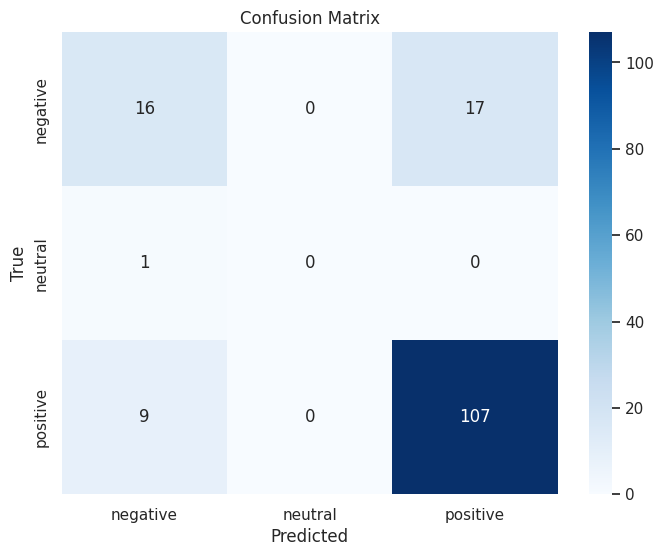

In [ ]:
plot_confusion_matrix(Y_test_classes, Y_pred_classes, labelencoder.classes_)

In [ ]:
# Save LSTM model
LSTM_model.save('model_LSTM.h5')

In [ ]:
# Texts prediction examples
texts = [
    "aplikasi dana sangat mudah digunakan untuk transaksi",
    "sering ada error dan aplikasi patah patah",
    "fitur bagus tapi sering error"
]

lstm_keras_tokenizer = tf.keras.preprocessing.text.Tokenizer(num_words=max_features, split=' ')
lstm_keras_tokenizer.fit_on_texts(df_prepocessed_text['content']) # Fit on the original preprocessed text data

for text in texts:
  text_processed = lstm_keras_tokenizer.texts_to_sequences([text])
  text_processed = pad_sequences(text_processed, maxlen=max_len)
  prediction = LSTM_model.predict(text_processed)

  # Decode the prediction for better readability
  predicted_class = np.argmax(prediction, axis=1)[0]
  predicted_label = labelencoder.inverse_transform([predicted_class])[0]
  confidence = np.max(prediction)
  print(f"Text: {text} -> Predicted: {predicted_label} (Confidence: {confidence:.4f})")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
Text: aplikasi dana sangat mudah digunakan untuk transaksi -> Predicted: positive (Confidence: 0.6639)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
Text: sering ada error dan aplikasi patah patah -> Predicted: negative (Confidence: 0.9868)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
Text: fitur bagus tapi sering error -> Predicted: negative (Confidence: 0.9131)


**Key Insights**💡
*   This model can correctly classifies 123 from 150 unseen reviews (**82% accuracy**). The LSTM model can be used for **monitoring** purposes but not reliable enough for autonomus critical decisions. It provides value as a first-layer filter to **prioritize which reviews need human attention**.
*   Out of 33 negative reviews, only 16 reviews correctly classified (recall = 48.5%). **17 negative reviews were misclassified** as positive (**51.5%**). Complaints regarding app performances, securities issues, etc could be misread as positive/neutral. It results a delayed response to solving the issues.

## **Model 2: IndoBERT**

In [ ]:
# Example assuming df_prepocessed_text is already in your environment
print(df_prepocessed_text.shape)
print(df_prepocessed_text["polarity"].value_counts())
print(df_prepocessed_text.head())

(1000, 3)
polarity
positive    801
negative    186
neutral      13
Name: count, dtype: int64
                                             content  score  polarity
0  bug lambat sinyal bagus aplikasi patah patah u...     -9  negative
1  atur susah paksa customer deposit 2x kena admi...     -1  negative
2  aplikasi dana bantu hidup tampil sederhana mud...     22  positive
3  tolong aplikasi dana bersih fitur game dana pl...      6  positive
4  alam dana instant error aju ulang lancar kah b...     10  positive


In [ ]:
model_name = "indolem/indobert-base-uncased"
tokenizer  = AutoTokenizer.from_pretrained(model_name)

label2id = {"negative": 0, "positive": 1, "neutral": 2}
id2label = {0: "negative", 1: "positive", 2: "neutral"}

class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts     = texts.tolist()
        self.labels    = [label2id[l] for l in labels.tolist()]
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/42.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [ ]:
X = df_prepocessed_text["content"]
Y = df_prepocessed_text["polarity"]

# 70% train / 15% val / 15% test
X_train, X_temp, Y_train, Y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=42, stratify=Y
)
X_val, X_test, Y_val, Y_test = train_test_split(
    X_temp, Y_temp, test_size=0.5, random_state=42, stratify=Y_temp
)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")

train_dataset = SentimentDataset(X_train, Y_train, tokenizer)
val_dataset   = SentimentDataset(X_val,   Y_val,   tokenizer)
test_dataset  = SentimentDataset(X_test,  Y_test,  tokenizer)

train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=8, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=8, shuffle=False)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train: 700 | Val: 150 | Test: 150
Train batches: 88 | Val batches: 19 | Test batches: 19


In [ ]:
def train_epoch(model, loader, optimizer, scheduler, device):
    model.train()
    total_loss, correct = 0, 0

    for batch in loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)

        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = outputs.logits.argmax(dim=1)
        correct += (preds == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)


def eval_epoch(model, loader, device):
    model.eval()
    total_loss, correct = 0, 0

    with torch.no_grad():
        for batch in loader:
            input_ids      = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels         = batch["labels"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            total_loss += outputs.loss.item()
            preds = outputs.logits.argmax(dim=1)
            correct += (preds == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

In [ ]:
import gc

# Reset any previous state
if 'model' in globals():
    del model
    gc.collect()
    torch.cuda.empty_cache()

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Fresh model
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3,
    id2label=id2label,
    label2id=label2id
).to(device)

# Verify trainable params
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable:,} / {total:,}")

# Optimizer & scheduler
EPOCHS      = 5
optimizer   = AdamW(model.parameters(), lr=2e-5, weight_decay=0.01)
total_steps = len(train_loader) * EPOCHS
scheduler   = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# History
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

# Training loop
print("\nStarting training...\n")
for epoch in range(EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, optimizer, scheduler, device)
    val_loss,   val_acc   = eval_epoch(model, val_loader, device)

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)

    print(f"Epoch {epoch+1}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | "
          f"Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}")

print("\nTraining complete!")

Using device: cpu


pytorch_model.bin:   0%|          | 0.00/445M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indolem/indobert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Trainable params: 110,560,515 / 110,560,515

Starting training...



Error during conversion: AttributeError("'str' object has no attribute 'decode'")


model.safetensors:   0%|          | 0.00/445M [00:00<?, ?B/s]

Epoch 1/5 | Train Loss: 0.6014 Acc: 0.7829 | Val Loss: 0.5436 Acc: 0.8000
Epoch 2/5 | Train Loss: 0.4607 Acc: 0.8200 | Val Loss: 0.5608 Acc: 0.8333
Epoch 3/5 | Train Loss: 0.3799 Acc: 0.8857 | Val Loss: 0.6395 Acc: 0.8267
Epoch 4/5 | Train Loss: 0.2480 Acc: 0.9300 | Val Loss: 0.8234 Acc: 0.8333
Epoch 5/5 | Train Loss: 0.2008 Acc: 0.9571 | Val Loss: 0.8283 Acc: 0.8400

Training complete!


In [ ]:
# save trained IndoBERT model
model.save_pretrained("model_indobert")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

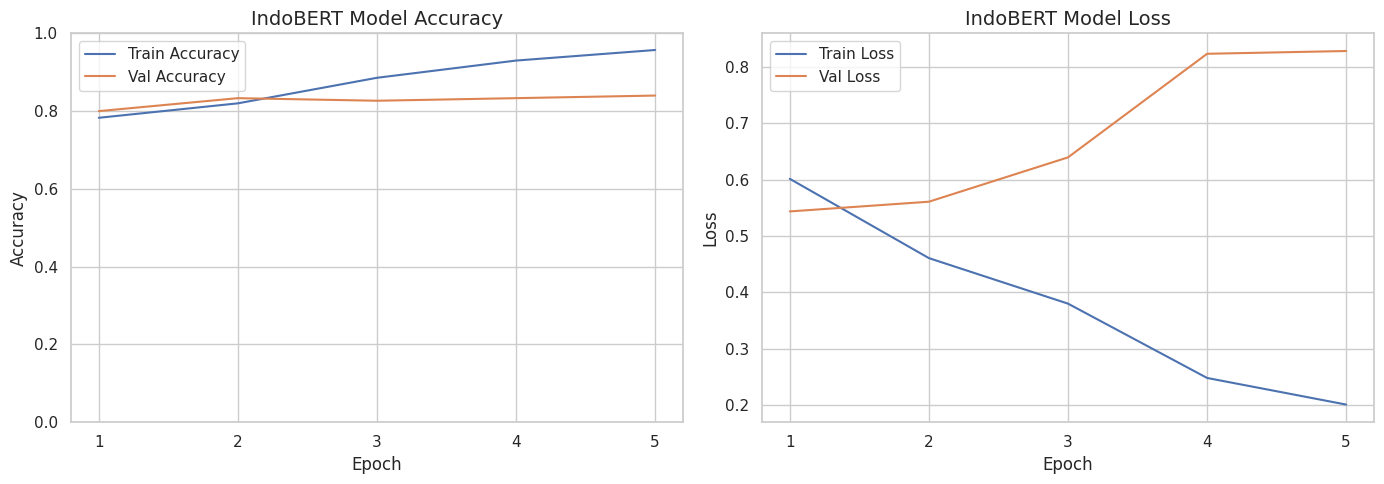

In [ ]:
def plot_training_history(history, EPOCHS):
    epochs = range(1, EPOCHS + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Accuracy
    axes[0].plot(epochs, history["train_acc"], label="Train Accuracy")
    axes[0].plot(epochs, history["val_acc"], label="Val Accuracy")
    axes[0].set_title("IndoBERT Model Accuracy", fontsize=14)
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Accuracy")
    axes[0].legend()
    axes[0].set_ylim(0, 1)
    axes[0].set_xticks(epochs)

    # Loss
    axes[1].plot(epochs, history["train_loss"], label="Train Loss")
    axes[1].plot(epochs, history["val_loss"], label="Val Loss")
    axes[1].set_title("IndoBERT Model Loss", fontsize=14)
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()
    axes[1].set_xticks(epochs)

    plt.tight_layout()
    plt.show()

plot_training_history(history, EPOCHS)

In [ ]:
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["labels"]

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        preds   = outputs.logits.argmax(dim=1).cpu().numpy()

        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

print(classification_report(
    all_labels, all_preds,
    target_names=["negative", "positive", "neutral"]
))

              precision    recall  f1-score   support

    negative       0.65      0.39      0.49        28
    positive       0.86      0.96      0.91       120
     neutral       0.00      0.00      0.00         2

    accuracy                           0.84       150
   macro avg       0.50      0.45      0.47       150
weighted avg       0.81      0.84      0.82       150



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


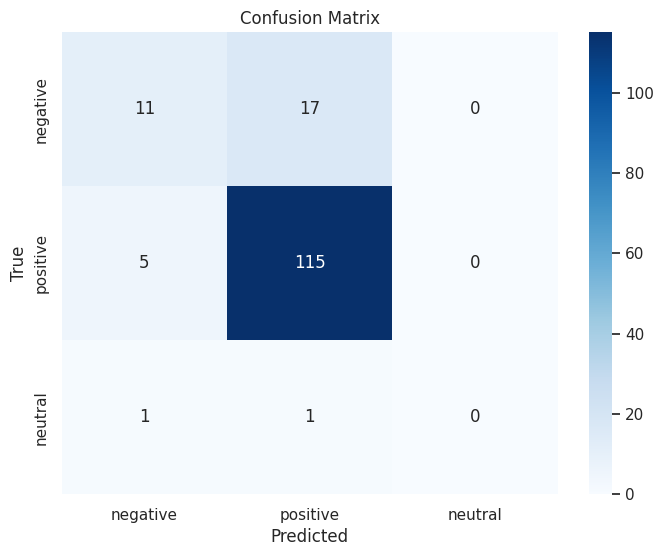

In [ ]:
# plot IndoBERT confusion matrix
plot_confusion_matrix(all_labels, all_preds, ["negative", "positive", "neutral"])

In [ ]:
def predict(text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(
        text,
        max_length=128,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )
    input_ids      = encoding["input_ids"].to(device)
    attention_mask = encoding["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids=input_ids, attention_mask=attention_mask).logits

    pred_id    = logits.argmax(dim=1).item()
    confidence = torch.softmax(logits, dim=1).max().item()

    return id2label[pred_id], round(confidence, 4)

# Text prediction examples
texts = [
    "aplikasi dana sangat mudah digunakan untuk transaksi",
    "sering ada error dan aplikasi patah patah",
    "fitur bagus tapi sering error"
]

for text in texts:
    label, conf = predict(text, model, tokenizer, device)
    print(f"Text      : {text}")
    print(f"Prediction: {label} (confidence: {conf})")
    print("-" * 60)

Text      : aplikasi dana sangat mudah digunakan untuk transaksi
Prediction: positive (confidence: 0.9967)
------------------------------------------------------------
Text      : sering ada error dan aplikasi patah patah
Prediction: negative (confidence: 0.9923)
------------------------------------------------------------
Text      : fitur bagus tapi sering error
Prediction: negative (confidence: 0.9871)
------------------------------------------------------------


**Key Insights**💡
*   This model can correctly classifies 126 from 150 unseen reviews (**84% accuracy**). The IndoBERT model can be used for **monitoring** purposes but not reliable enough for autonomus critical decisions. It provides value as a first-layer filter to **prioritize which reviews need human attention**.
*   Out of 28 negative reviews, only 11 reviews correctly classfied (recall = 39%). **17 negative reviews were misclassified** as positive (**61%**). Complaints regarding app performances, securities issues, etc could be misread as positive/neutral. It results a delayed response to solving the issues.

# **Conclusion**

*   **Model 1 (LSTM) catches more negative reviews proportionally**. Despite both missing 17 negative reviews, Model 1 correctly identifies 48.5% negative reviews meanwhile Model 2 (IndoBERT) only 39%. Therefore, Model 1 is more effective at preventing issues caused by undetected negative reviews such as user churn, unsolved security risks, and reputational damage.
*   For this case neither model is ready for autonomus critical decision-making, but as complaints monitoring tool, **Model 1 (LSTM) is safer** than Model 2 (IndoBERT). It will escalate complaints better than Model 2.
